### Artificial Neural Networks (ANN)

When beginning to understand deep learning, we need to understand model abstractions:

- Single biological neuron
- Perceptron
- Multi-layer perceptron model
- Deep learning neural network

Other key concepts include:

- Activation functions
- Gradient descent
- BackPropagation
  

The perceptron model mimics a simple biological neuron model. This can be viewed as:

Inputs ($X$) -> $f(X)$ -> Output(s)

In order to learn, we adjust some parameters. Thus, we add adjustable weights to inputs to get the correct value of output ($y$).

If input is zero, no change. Thus, we add a bias term ($b$) / offset value.


#### Neural Networks

A single perceptron won't be enough to learn complicated systems. For that, we can expand the idea to a multi-layer perceptron model.

multi-layer perceptron model: connect layers of perceptrons

Note: Fully connected network: Every perceptron in one layer connects to every perceptron/neuron in the next layer.

First layer == Input layer

Last layer == output layer (there could be more than one neuron)

Layers between input and output layers == hidden layers (difficult to interpret due to high interconnectivity. It is hard to see what a single neuron is picking up)

When does it become a deep neural network? If it contains 2 or more hidden layers.

A neural network framework can be used to approximate any (convex continuous) function.
Link: https://en.wikipedia.org/wiki/Universal_approximation_theorem

In most cases, we do not want $f(X)$ to be a simple summation (Example: classification task. The output needs to be between 0 and 1). Thus, we use activation functions.

#### Activations Functions

Set a contraint to the output value. For example, in a binary classification problem, we expect the output to be 0 or 1. In such a situation, we can set rules when the output is below zero, when the output is zero, and when it is above zero, the output is one. 

In the above case, the change is very dramatic and does not reflect a small change. Instead, we can try the sigmoid function (logistic function), which is more smooth/sensitive to small changes (Note: Output is between 0 and 1).

Other popular activation functions:

- Hyperbolic Tangent: tanh(Z). Output is between -1 and 1.
- Recified Linear Unit (ReLU) == max(0,z). If the output is below 0, the value is zero, and if above zero, no change. It shows overall good performance (when dealing with vanishing gradient). Link: https://en.wikipedia.org/wiki/Activation_function


#### Multi-Class Classification

The activation functions discussed above are for single output (continuous label or binary classification). But in some cases, we have multi-class situations. That is, the output layer has multiple neurons.

There are 2 main types of multi-class situations.

- Non-Exclusive Classes: A data point can have multiple classes/categories assigned to it.

Example: The data are photos. Photos can have multiple tags: beach, family, vacation, ...

- Mutually Exclusive Classes: Only one class per data point (**most common type).

Example: Photos. Categorized as being in grayscale (black and white) or full color.

**How to organize data that contains multiple classes?** The easiest way is output a node per class. Here, we need to organize the categories for the output layer (we cannot simply add/feed words/categories). Thus, we can transform data, and we can use **one-hot encoding** / dummy variables for mutually exclusive classes.

Note: One Hot Encoding is a method for converting categorical variables into a binary format. It creates new columns for each category where 1 means the category is present and 0 means it is not.

For non-exclusive classes, this is slightly different. A similar method can be used. But here, each data point has 1 in all related categories.

Then, in the last output layer, we should choose the correct activation functions. For **non-exclusive classes**, we can use the **sigmoid function**.

For **mutually exclusive classes**, we can use the **softmax function**. It will calculate probability distributions of the event over K different events. In the output layers, the sum of all the probabilities will be equal to 1. Then we will choose the one with the highest probability.



#### Cost Functions and Gradient Descent

Ones obtain the outputs, we need to compare them against the real values (this is during the fitting/training period of the model). For this, we will use a **cost function** / **loss function**. This tells how far we are away from true values. We keep track of the loss/cost, and with each epoch, we expect it to go down.

Most common cost function: Quadratic cost function (similar to MSE with absolute differences). Since we are squaring it, it punishes large errors.

Cost function is a function of: network weights, biases, input, and desired output of the training sample.

In real cases, the cost function depends on lots of weights. The, how do we know which weights lead us to the lowest cost? For a very simple cost function, we can take the derivative. For high-dimensional cases, we can use gradient descent. We start by calculating the slope at a point and move in the downward direction. We can take smaller (slower) / larger (overshoot the minimum point) steps, and this is known as the learning rate. We can also adapt, and this is known as "adaptive gradient descent" (Example: Adam optimizer).

For classification problems, we often use cross entropy loss function. It assumes the model predict prbability distribution for each class.


#### BackPropagation

Basically, we would like to know how the cost function results change with respect to the weights in the network.
So that we can update the weights to minimize the cost.

In usual notation, layers are numbered as (left to right): L-n -> ... -> L-2 -> L-1 -> L

Then, output of layer L: $Z^{L} = q^{L}a^{L-1} + b^{L}$, $a^{L} = \sigma(z^{L})$ is the output from the previous layer.

We want to understand how sensitive the cost function is to the changes in $w$. This is where the partial derivative comes in (here we apply the chain rule). We can also calculate the partial derivative for the bias terms. The main idea is that we can use the gradient to go back through the network and adjust our weights and biases to minimize the output of the error vector in the last output layer (Hadamard product: (error vector X output)).


#### PyTorch Gradients

Here we are trying to see how PyTorch implements gradient descent using its auto gradient function.

In [1]:
import torch

In [3]:
x = torch.tensor(2.0, requires_grad = True) ### This sets up computational tracking on the tensor.

In [4]:
### Define a function

y = 2*x**4 + x**3 + 3*x**2 + 5*x + 1

In [5]:
print(y)

### When you plus x as 2.

tensor(63., grad_fn=<AddBackward0>)


In [ ]:
y.backward() ### BackPropogation

Derivative: $y' = 8x^3 + 3x^2 + 6x + 5 $

In [8]:
x.grad

### 93 is the representation of if you plug x = 2 to first derivative.

tensor(93.)

In the above what we see is single backpropogation.

Now we performe backropagation on multiple steps.

In [16]:
x = torch.tensor([[1.,2.,3.],[3.,2.,1.]], requires_grad = True)

In [17]:
print(x)

tensor([[1., 2., 3.],
        [3., 2., 1.]], requires_grad=True)


In [18]:
### First function:

y = 3*x + 2

In [19]:
print(y)

tensor([[ 5.,  8., 11.],
        [11.,  8.,  5.]], grad_fn=<AddBackward0>)


In [20]:
### Another function: Can view as the second layer.

z = 2*y**2

In [21]:
print(z)

tensor([[ 50., 128., 242.],
        [242., 128.,  50.]], grad_fn=<MulBackward0>)


In [22]:
### Output:

out = z.mean()

In [23]:
print(out)

tensor(140., grad_fn=<MeanBackward0>)


In [24]:
### backpropogation:

out.backward()

In [25]:
print(x.grad)

tensor([[10., 16., 22.],
        [22., 16., 10.]])


You should see a 2x3 matrix. If we call the final <tt>out</tt> tensor "$o$", we can calculate the partial derivative of $o$ with respect to $x_i$ as follows:<br>

$o = \frac {1} {6}\sum_{i=1}^{6} z_i$<br>

$z_i = 2(y_i)^2 = 2(3x_i+2)^2$<br>

To solve the derivative of $z_i$ we use the <a href='https://en.wikipedia.org/wiki/Chain_rule'>chain rule</a>, where the derivative of $f(g(x)) = f'(g(x))g'(x)$<br>

In this case<br>

$\begin{split} f(g(x)) &= 2(g(x))^2, \quad &f'(g(x)) = 4g(x) \\
g(x) &= 3x+2, &g'(x) = 3 \\
\frac {dz} {dx} &= 4g(x)\times 3 &= 12(3x+2) \end{split}$

Therefore,<br>

$\frac{\partial o}{\partial x_i} = \frac{1}{6}\times 12(3x+2)$<br>

$\frac{\partial o}{\partial x_i}\bigr\rvert_{x_i=1} = 2(3(1)+2) = 10$

$\frac{\partial o}{\partial x_i}\bigr\rvert_{x_i=2} = 2(3(2)+2) = 16$

$\frac{\partial o}{\partial x_i}\bigr\rvert_{x_i=3} = 2(3(3)+2) = 22$

#### Linear Regression with PyTorch

In [26]:
import torch

import numpy as np
import matplotlib.pyplot as plt

In [27]:
import torch.nn as nn

In [31]:
X = torch.linspace(1,50,50).reshape(-1,1) ### Linearly spaced elements

In [32]:
torch.manual_seed(71)

### Error values:
e = torch.randint(-8,9,(50,1), dtype=torch.float)

In [34]:
### Our formula:

y = 2*X + 1 + e
y.shape

torch.Size([50, 1])

In [35]:
### For plotting purposes, we need to convert it back to numpy

X.numpy()

array([[ 1.],
       [ 2.],
       [ 3.],
       [ 4.],
       [ 5.],
       [ 6.],
       [ 7.],
       [ 8.],
       [ 9.],
       [10.],
       [11.],
       [12.],
       [13.],
       [14.],
       [15.],
       [16.],
       [17.],
       [18.],
       [19.],
       [20.],
       [21.],
       [22.],
       [23.],
       [24.],
       [25.],
       [26.],
       [27.],
       [28.],
       [29.],
       [30.],
       [31.],
       [32.],
       [33.],
       [34.],
       [35.],
       [36.],
       [37.],
       [38.],
       [39.],
       [40.],
       [41.],
       [42.],
       [43.],
       [44.],
       [45.],
       [46.],
       [47.],
       [48.],
       [49.],
       [50.]], dtype=float32)

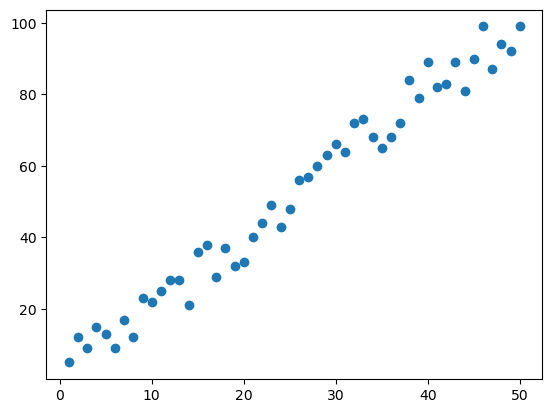

In [36]:
plt.scatter(X.numpy(), y.numpy());

We want to use PyTorch and fit a simple linear regression here.

When we set up X, we did not mention "grad_fn". Thus, it does not track opearions and it does not know the relationship between X and y.

First we want to see weights and bias. We only have one input and one output.

In [37]:
torch.manual_seed(59)

model = nn.Linear(in_features=1, out_features=1)

print(model.weight)
print(model.bias)

Parameter containing:
tensor([[0.1060]], requires_grad=True)
Parameter containing:
tensor([0.9638], requires_grad=True)


In [38]:
### Now we set up the model classes:

class Model(nn.Module):

    def __init__(self, in_features, out_features):

        super().__init__()
        self.linear = nn.Linear(in_features, out_features) 

    def forward(self,x):
        y_pred = self.linear(x)
        return y_pred

This defines a simple **linear regression model** in PyTorch:

- **`class Model(nn.Module)`** — inherits from PyTorch's base `nn.Module` class, which is the foundation for all neural network models.
- **`__init__`** — the constructor takes `in_features` and `out_features` as arguments and creates a single linear layer (`nn.Linear`), which applies the transformation **y = xW + b**.
- **`forward`** — defines the forward pass. When you call the model with input `x`, it passes the data through the linear layer and returns a prediction `y_pred`.

In short, this is a minimal single-layer neural network suited for tasks like linear regression.

Moreover, the linear model layer (nn.Linear) does not refer to linear regression. It defines a type of neural network layer employed here. A linear layer is a dense / fully connected layer, and moving forward, we would have a linear layer/convolution layer/pooling layer, and so on.
